# Adaptive decoder: saved-run analysis

This notebook reads an existing canonical YAML run. It does not run a simulation. Set `run_path`, `filter`, and `group_by` below. The first `group_by` field controls line color; the second controls marker shape. Up to two fields are supported. The boxed legend occupies its own top region, while the main plotting area has a fixed physical size. Confidence bands are 99% Wilson intervals.

In [18]:
from pathlib import Path
import importlib
import sys
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload local modules when this cell is rerun in an existing kernel.
import color_code_softoutput.simulation.config as workflow_config
import color_code_softoutput.analysis.color_correlated as color_correlated_analysis
importlib.reload(workflow_config)
importlib.reload(color_correlated_analysis)
ColorCorrelatedRun = color_correlated_analysis.ColorCorrelatedRun

# Edit this path to select a completed run.
run_path = PROJECT_ROOT / "results/26_09_27_21_03_06_57c0a1f5"
run = ColorCorrelatedRun(run_path)
print("Run:", run.run_directory)
print("Start:", run.run_log["simulation_start_time"])
print("End:", run.run_log["simulation_end_time"])
print("Planned points:", len(run.catalog))
print("logical_error files present:", int(run.catalog["data_available"].sum()), "/", len(run.catalog))

Run: /home/quantum_teresheys/workspace/color_code_softoutput/results/26_09_27_21_03_06_57c0a1f5
Start: 2026-09-27T21:03:06.959300+09:00
End: 2026-09-27T21:06:07.062341+09:00
Planned points: 18
logical_error files present: 18 / 18


## Confirm the configuration and available points

`run_log.json` supplies the saved configuration. The catalog lists every planned point and whether its `logical_error.parquet` is present. Aggregation also validates metric schemas, row counts, and shot indices.

In [19]:
display(run.run_log["config"])
display(run.catalog)

{'simulation': {'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/results',
  'shots': 100000,
  'workers': 6,
  'master_seed': 20260927,
  'buffer_shots': 1000,
  'verbose': True},
 'chunking': {'calibration_shots': 100,
  'target_chunk_seconds': 4.0,
  'min_chunk_shots': 1,
  'max_chunk_shots': 1000,
  'throughput_ema_alpha': 0.5},
 'sweep': {'distance': [7, 9],
  'physical_error_rate': [0.02, 0.03, 0.04],
  'noise_model': ['bitflip'],
  'rounds': [1],
  'circuit_type': ['tri'],
  'cnot_schedule': ['tri_optimal']},
 'color_code_options': {'temp_bdry_type': 'Z'},
 'decoders': [{'type': 'color_correlated',
   'options': {'color_correlated_b': 2.0,
    'enable_colorcorrelated_decoding': True,
    'remove_non_edge_like_errors': True},
   'decode_options': {}},
  {'type': 'perturbation',
   'options': {'color_correlated_weight_basis': 'original_dem',
    'enable_prior_perturbation': True,
    'perturbation_alpha': 1.0,
    'perturbation_ensemble_size': 12,
    'pertu

,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,color_correlated,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True
1,perturbation,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_type=perturbation,circuit_type=tri,d=7...",True
2,tesseract,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_type=tesseract,circuit_type=tri,d=7,r=...",True
3,color_correlated,tri,7,1,0.03,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True
4,perturbation,tri,7,1,0.03,bitflip,tri_optimal,100000,"decoder_type=perturbation,circuit_type=tri,d=7...",True
5,tesseract,tri,7,1,0.03,bitflip,tri_optimal,100000,"decoder_type=tesseract,circuit_type=tri,d=7,r=...",True
6,color_correlated,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True
7,perturbation,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_type=perturbation,circuit_type=tri,d=7...",True
8,tesseract,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_type=tesseract,circuit_type=tri,d=7,r=...",True
9,color_correlated,tri,9,1,0.02,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True


## Choose conditions and line styles

Use scalar or list values in `filter`, for example `{"distance": [3, 5], "noise_model": "depol"}`. Available fields are `decoder_type`, `circuit_type`, `distance`, `rounds`, `physical_error_rate`, `noise_model`, and `cnot_schedule`. Omitted filters include all values. Set `baseline_compare=True` to add one representative `decoder_type=baseline` per physical condition from advanced decoder `default_logical_error.parquet` files. Each baseline is paired with its own advanced decoder shots; decoder types can have independently sampled shots. `concat_mwpm` points are separate runs. Include `decoder_type` in `group_by` when comparing the baseline. Every parameter that varies in the selected points (except physical error rate) must appear in `group_by` or be fixed by `filter`.

In [20]:
filter = {
    # "distance": [3, 5],
    # "decoder_type": ["concat_mwpm", "color_correlated", "relifting", "perturbation"],
}
better_weight_filter = filter  # set a separate mapping to filter this table
effect_filter = filter  # set a separate mapping to filter this table
group_by = ["distance", "decoder_type"]  # first: color; second: marker
baseline_compare = True  # one paired baseline per physical condition
yscale = "log"  # "log" or "linear"
plot_width = 7.4  # inches; independent of legend size
plot_height = 4.6  # inches; independent of legend size
legend_fontsize = 9
legend_row_height = 0.48  # inches per first-group value
save_figure = True

print("Selected points:")
display(run.select(filter))

Selected points:


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,color_correlated,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True
1,perturbation,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_type=perturbation,circuit_type=tri,d=7...",True
2,tesseract,tri,7,1,0.02,bitflip,tri_optimal,100000,"decoder_type=tesseract,circuit_type=tri,d=7,r=...",True
3,color_correlated,tri,7,1,0.03,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True
4,perturbation,tri,7,1,0.03,bitflip,tri_optimal,100000,"decoder_type=perturbation,circuit_type=tri,d=7...",True
5,tesseract,tri,7,1,0.03,bitflip,tri_optimal,100000,"decoder_type=tesseract,circuit_type=tri,d=7,r=...",True
6,color_correlated,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True
7,perturbation,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_type=perturbation,circuit_type=tri,d=7...",True
8,tesseract,tri,7,1,0.04,bitflip,tri_optimal,100000,"decoder_type=tesseract,circuit_type=tri,d=7,r=...",True
9,color_correlated,tri,9,1,0.02,bitflip,tri_optimal,100000,"decoder_type=color_correlated,circuit_type=tri...",True


## Logical error rate versus physical error rate

The returned table includes shots, failures, LER, and 99% Wilson bounds for every plotted point. With baseline comparison enabled, `metric` identifies which saved file supplies each curve and `source_decoder_type` identifies the source experiment.
On a log axis, a zero-failure point is displayed at 0.5/shots so it remains visible. The numeric table keeps the measured LER of zero.

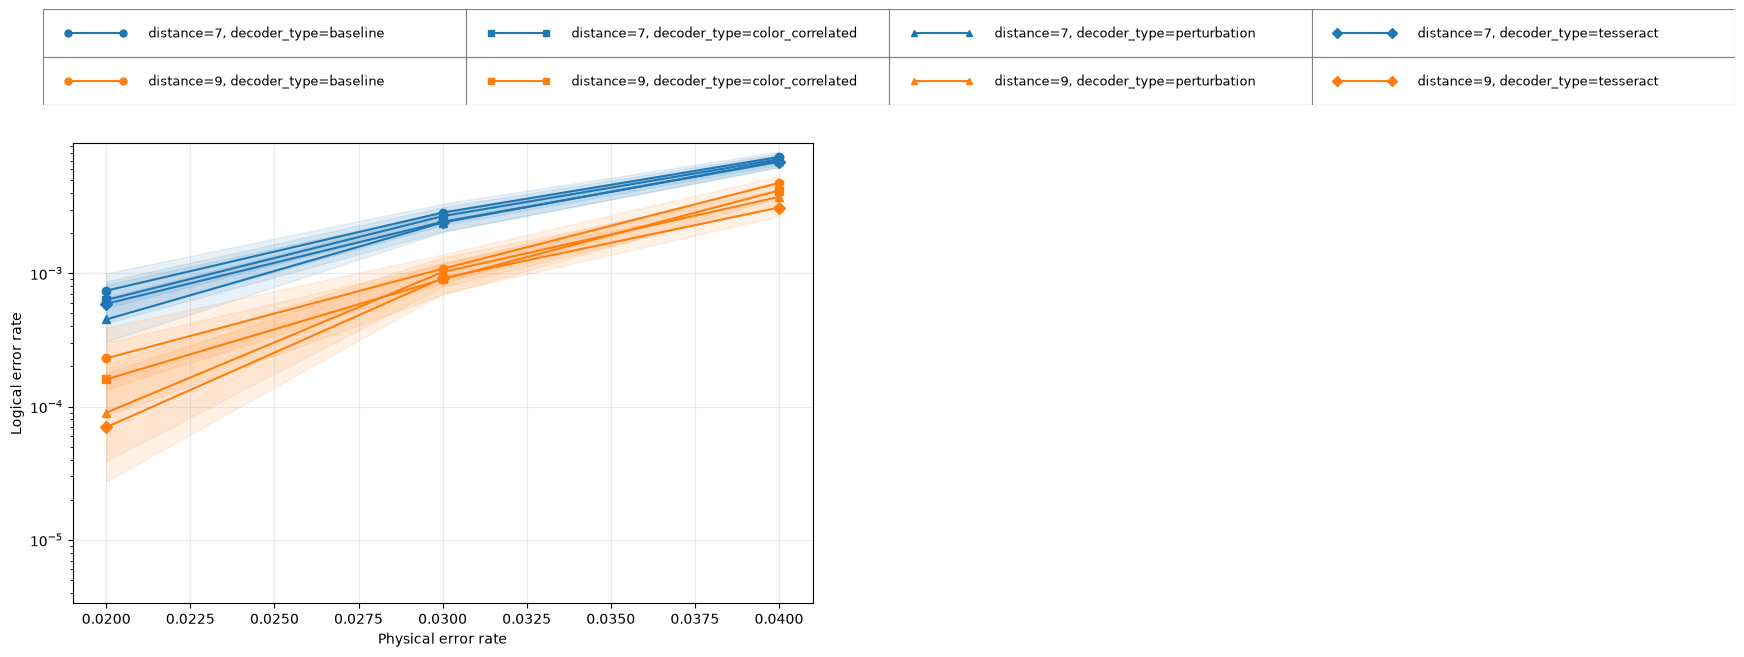

,distance,decoder_type,source_decoder_type,metric,physical_error_rate,shots,failures,logical_error_rate,ler_low,ler_high
0,7,baseline,color_correlated,default_logical_error,0.02,100000,74,0.00074,0.000549,0.000997
1,7,color_correlated,color_correlated,logical_error,0.02,100000,63,0.00063,0.000456,0.000870
2,7,perturbation,perturbation,logical_error,0.02,100000,45,0.00045,0.000307,0.000659
3,7,tesseract,tesseract,logical_error,0.02,100000,59,0.00059,0.000423,0.000824
4,7,baseline,color_correlated,default_logical_error,0.03,100000,285,0.00285,0.002448,0.003318
5,7,color_correlated,color_correlated,logical_error,0.03,100000,268,0.00268,0.002291,0.003135
6,7,perturbation,perturbation,logical_error,0.03,100000,240,0.00240,0.002033,0.002833
7,7,tesseract,tesseract,logical_error,0.03,100000,243,0.00243,0.002061,0.002865
8,7,baseline,color_correlated,default_logical_error,0.04,100000,744,0.00744,0.006772,0.008173
9,7,color_correlated,color_correlated,logical_error,0.04,100000,716,0.00716,0.006505,0.007880


Saved figure: /home/quantum_teresheys/workspace/color_code_softoutput/results/26_09_27_21_03_06_57c0a1f5/analysis/color_correlated_ler_with_baseline.png


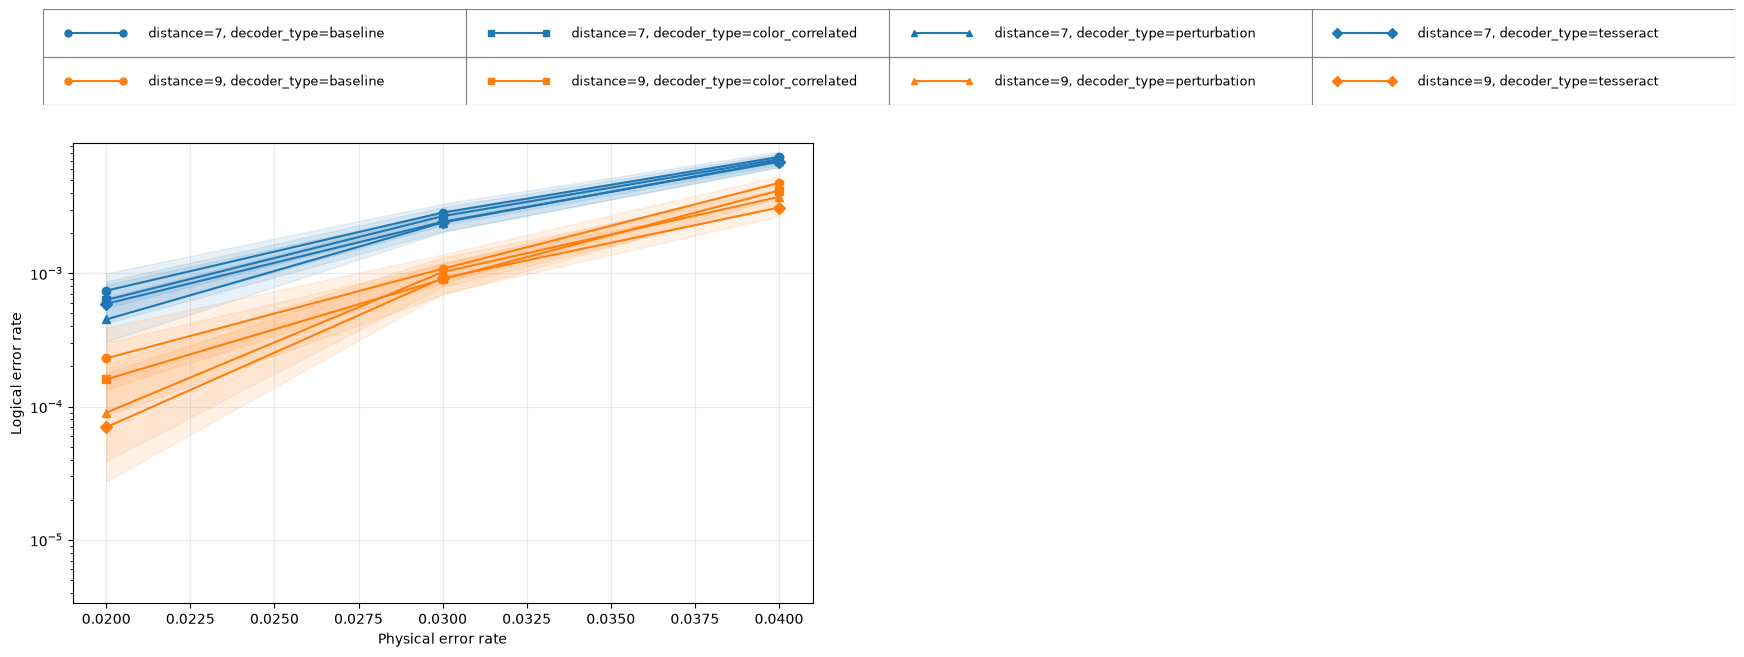

In [21]:
figure, axes, ler_table = run.plot_ler(
    filter=filter,
    group_by=group_by,
    baseline_compare=baseline_compare,
    yscale=yscale,
    plot_width=plot_width,
    plot_height=plot_height,
    legend_fontsize=legend_fontsize,
    legend_row_height=legend_row_height,
)
display(figure)
columns = ["distance", "decoder_type", "physical_error_rate", "shots", "failures", "logical_error_rate", "ler_low", "ler_high"]
if baseline_compare:
    columns[2:2] = ["source_decoder_type", "metric"]
display(ler_table[columns])
if save_figure:
    output_dir = run.run_directory / "analysis"
    output_dir.mkdir(exist_ok=True)
    figure_name = "color_correlated_ler_with_baseline.png" if baseline_compare else "color_correlated_ler.png"
    figure_path = output_dir / figure_name
    figure.savefig(figure_path, dpi=200, bbox_inches="tight")
    print("Saved figure:", figure_path)

## Correlated-decoding counts by experiment condition

The first table counts lower-weight candidates. In the second table, `effect_count` counts shots rescued relative to the paired baseline, `worsened_count` counts shots where the baseline succeeded but the selected decoder failed, and `net_effect_count = effect_count - worsened_count`. Positive net values mean fewer logical failures. These counts are blank for ordinary decoder points because paired baseline files are not produced. `shots` is the denominator for each count.

In [22]:
display(run.better_weight_table(filter=better_weight_filter))
display(run.effect_table(filter=effect_filter))


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,shots,better_weight_count
0,color_correlated,tri,7,1,0.02,bitflip,tri_optimal,100000,15
1,perturbation,tri,7,1,0.02,bitflip,tri_optimal,100000,19
2,tesseract,tri,7,1,0.02,bitflip,tri_optimal,100000,<NA>
3,color_correlated,tri,7,1,0.03,bitflip,tri_optimal,100000,38
4,perturbation,tri,7,1,0.03,bitflip,tri_optimal,100000,50
5,tesseract,tri,7,1,0.03,bitflip,tri_optimal,100000,<NA>
6,color_correlated,tri,7,1,0.04,bitflip,tri_optimal,100000,131
7,perturbation,tri,7,1,0.04,bitflip,tri_optimal,100000,523
8,tesseract,tri,7,1,0.04,bitflip,tri_optimal,100000,<NA>
9,color_correlated,tri,9,1,0.02,bitflip,tri_optimal,100000,24


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,shots,effect_count,worsened_count,net_effect_count
0,color_correlated,tri,7,1,0.02,bitflip,tri_optimal,100000,11,0,11
1,perturbation,tri,7,1,0.02,bitflip,tri_optimal,100000,10,1,9
2,tesseract,tri,7,1,0.02,bitflip,tri_optimal,100000,<NA>,<NA>,<NA>
3,color_correlated,tri,7,1,0.03,bitflip,tri_optimal,100000,21,4,17
4,perturbation,tri,7,1,0.03,bitflip,tri_optimal,100000,32,7,25
5,tesseract,tri,7,1,0.03,bitflip,tri_optimal,100000,<NA>,<NA>,<NA>
6,color_correlated,tri,7,1,0.04,bitflip,tri_optimal,100000,42,14,28
7,perturbation,tri,7,1,0.04,bitflip,tri_optimal,100000,83,12,71
8,tesseract,tri,7,1,0.04,bitflip,tri_optimal,100000,<NA>,<NA>,<NA>
9,color_correlated,tri,9,1,0.02,bitflip,tri_optimal,100000,7,0,7
